In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
evaluations = pd.read_csv('data/extrait_eval.csv')
evaluations.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


In [2]:
evaluations.shape

NameError: name 'evaluations' is not defined

In [ ]:
employes = pd.read_csv('data/extrait_sirh.csv')
employes.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [6]:
employes.shape

(1470, 12)

In [ ]:
sondage = pd.read_csv('data/extrait_sondage.csv')
sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [8]:
sondage.shape

(1470, 12)

In [9]:
combined = pd.concat([evaluations, employes, sondage], axis=0)
combined.reset_index(drop=True, inplace=True)
combined.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,2.0,3.0,2.0,4.0,1.0,1.0,E_1,3.0,Oui,11 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,2.0,2.0,2.0,4.0,3.0,E_2,4.0,Non,23 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,2.0,1.0,3.0,2.0,3.0,E_4,3.0,Oui,15 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,3.0,1.0,3.0,3.0,3.0,E_5,3.0,Oui,11 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,3.0,1.0,2.0,4.0,3.0,E_7,3.0,Non,12 %,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# -------------------------------
# 1) Nettoyage eval_number → id_employee
# -------------------------------

eval = evaluations.copy()

eval["id_employee"] = (
    eval["eval_number"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype("Int64")
)

print(">>> Aperçu conversion eval_number → id_employee :")
print(eval[["eval_number", "id_employee"]].head(), "\n")

# Vérification : identifiants valides
missing_eval_ids = set(eval["id_employee"]) - set(employes["id_employee"])
print("IDs dans eval absents de employes :", missing_eval_ids, "\n")


# -------------------------------
# 2) MERGE employes ↔ eval
# -------------------------------
merged = employes.merge(
    eval,
    on="id_employee",
    how="inner",
    suffixes=("_emp", "_eval")
)
print("Après merge employes + eval :", merged.shape)


# -------------------------------
# 3) MERGE avec sondage
# -------------------------------
missing_survey_ids = set(sondage["code_sondage"]) - set(employes["id_employee"])
print("IDs dans sondage absents de employes :", missing_survey_ids, "\n")

merged = merged.merge(
    sondage,
    left_on="id_employee",
    right_on="code_sondage",
    how="inner",
    suffixes=("", "_sondage")
)

print("Après merge complet :", merged.shape)


# -------------------------------
# 4) Nettoyage colonnes redondantes
# -------------------------------
for col in ["eval_number", "code_sondage"]:
    if col in merged.columns:
        merged.drop(columns=col, inplace=True)

print("\nColonnes finales :", len(merged.columns))
print("Liste colonnes :", merged.columns.tolist(), "\n")

merged.head()

>>> Aperçu conversion eval_number → id_employee :
  eval_number  id_employee
0         E_1            1
1         E_2            2
2         E_4            4
3         E_5            5
4         E_7            7 

IDs dans eval absents de employes : set() 

Après merge employes + eval : (1470, 22)
IDs dans sondage absents de employes : set() 

Après merge complet : (1470, 34)

Colonnes finales : 32
Liste colonnes : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'nombre_par

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [11]:
merged.info()
merged.value_counts()
merged.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   id_employee                                1470 non-null   int64 
 1   age                                        1470 non-null   int64 
 2   genre                                      1470 non-null   object
 3   revenu_mensuel                             1470 non-null   int64 
 4   statut_marital                             1470 non-null   object
 5   departement                                1470 non-null   object
 6   poste                                      1470 non-null   object
 7   nombre_experiences_precedentes             1470 non-null   int64 
 8   nombre_heures_travailless                  1470 non-null   int64 
 9   annee_experience_totale                    1470 non-null   int64 
 10  annees_dans_l_entreprise            

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [12]:
merged.describe(include='all')

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470,1470.000000,1470,1470,1470,1470.000000,1470.0,1470.000000,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470,1470,1470,1470.000000,1470.000000
unique,NaN,NaN,2,NaN,3,3,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6,1,3,NaN,NaN
top,NaN,NaN,M,NaN,Marié(e),Consulting,Cadre Commercial,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Infra & Cloud,Y,Occasionnel,NaN,NaN
freq,NaN,NaN,882,NaN,673,961,326,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,606,1470,1043,NaN,NaN
mean,1024.865306,36.923810,NaN,6502.931293,NaN,NaN,NaN,2.693197,80.0,11.279592,...,0.793878,2.799320,1.0,9.192517,2.912925,NaN,NaN,NaN,2.187755,4.123129
std,602.024335,9.135373,NaN,4707.956783,NaN,NaN,NaN,2.498009,0.0,7.780782,...,0.852077,1.289271,0.0,8.106864,1.024165,NaN,NaN,NaN,3.222430,3.568136
min,1.000000,18.000000,NaN,1009.000000,NaN,NaN,NaN,0.000000,80.0,0.000000,...,0.000000,0.000000,1.0,1.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000
25%,491.250000,30.000000,NaN,2911.000000,NaN,NaN,NaN,1.000000,80.0,6.000000,...,0.000000,2.000000,1.0,2.000000,2.000000,NaN,NaN,NaN,0.000000,2.000000
50%,1020.500000,36.000000,NaN,4919.000000,NaN,NaN,NaN,2.000000,80.0,10.000000,...,1.000000,3.000000,1.0,7.000000,3.000000,NaN,NaN,NaN,1.000000,3.000000
75%,1555.750000,43.000000,NaN,8379.000000,NaN,NaN,NaN,4.000000,80.0,15.000000,...,1.000000,3.000000,1.0,14.000000,4.000000,NaN,NaN,NaN,3.000000,7.000000


In [13]:
merged.columns


Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

Le graphique montre une distribution déséquilibrée de la variable a_quitter_entreprise, avec une majorité d’employés n’ayant pas quitté l’entreprise (“Non”) et une minorité l’ayant quittée (“Oui”)



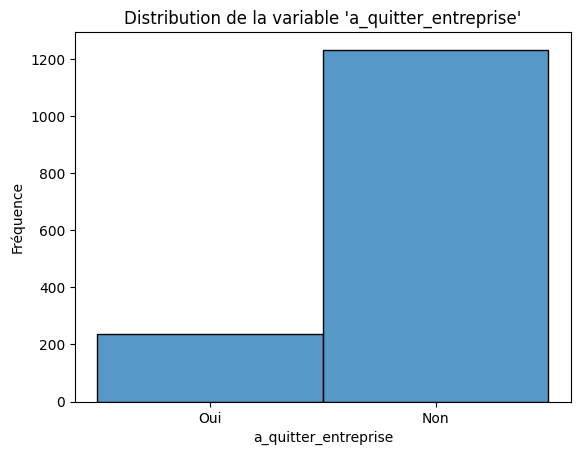

In [14]:
sns.histplot(merged['a_quitte_l_entreprise']);
plt.title("Distribution de la variable 'a_quitter_entreprise'");
plt.xlabel('a_quitter_entreprise')
plt.ylabel('Fréquence')
plt.show()

Ce boxplot compare la distribution de l’âge selon le départ de l’entreprise et le genre. Les employés ayant quitté l’entreprise (“Oui”) sont en moyenne plus jeunes que ceux restés (“Non”). Les distributions d’âge entre femmes et hommes sont globalement similaires, avec une variabilité légèrement plus élevée chez les employés restés dans l’entreprise.

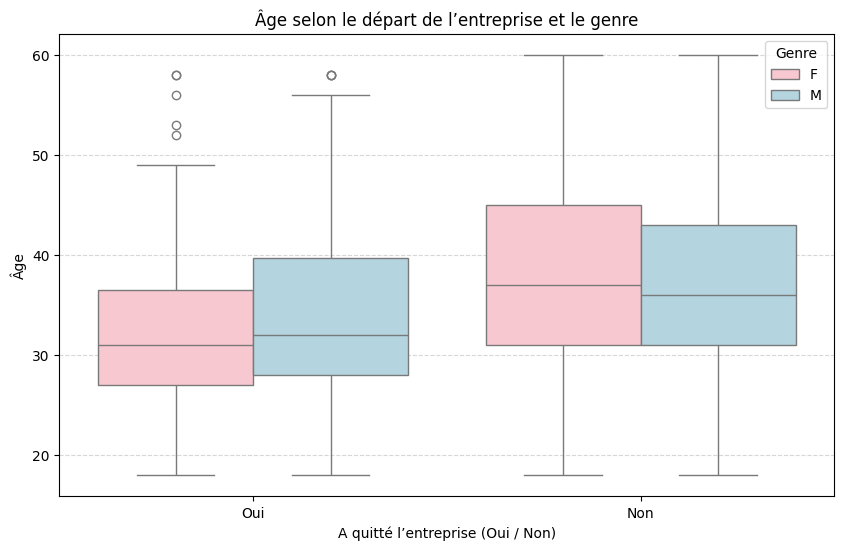

In [15]:
# --- Nettoyage des colonnes utiles ---
merged["a_quitte_l_entreprise"] = (
    merged["a_quitte_l_entreprise"]
    .astype(str)
    .str.strip()
    .replace({"nan": np.nan})
)

merged["genre"] = merged["genre"].astype(str).str.strip()

# --- Suppression des lignes incomplètes ---
merged_filtered = merged.dropna(subset=["a_quitte_l_entreprise", "age", "genre"])

# --- Tracé du boxplot groupé par genre ---
plt.figure(figsize=(10,6))
sns.boxplot(
    x="a_quitte_l_entreprise",
    y="age",
    hue="genre",
    data=merged_filtered,
    palette={
        "F": "pink",
        "M": "lightblue"
    }
)

plt.xlabel("A quitté l’entreprise (Oui / Non)")
plt.ylabel("Âge")
plt.title("Âge selon le départ de l’entreprise et le genre")
plt.legend(title="Genre")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Ce graphique de dispersion montre la relation entre l’âge et le revenu mensuel selon le départ de l’entreprise. On observe une tendance générale à l’augmentation du revenu avec l’âge. Les employés ayant quitté l’entreprise (“Oui”) sont présents à tous les niveaux de revenus, mais apparaissent plus fréquemment dans les tranches de revenus faibles à intermédiaires, tandis que les employés restés (“Non”) sont majoritaires, notamment aux revenus plus élevés.

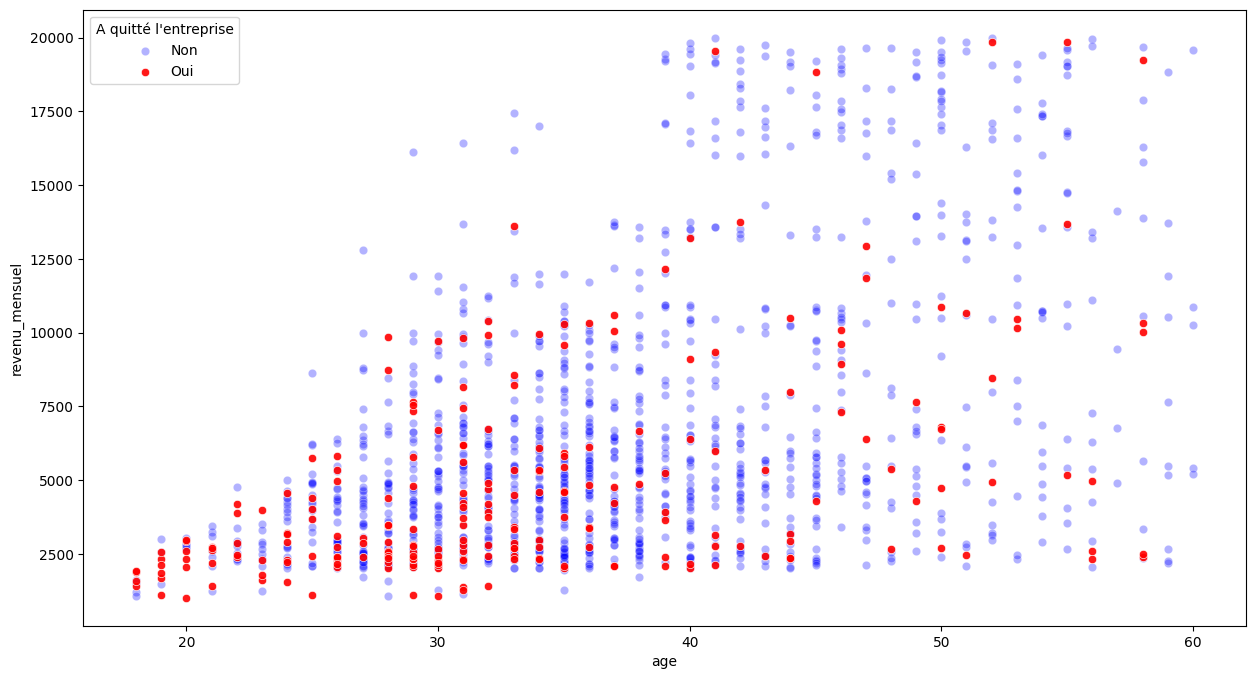

In [16]:

plt.figure(figsize=(15, 8))


sns.scatterplot(
    data=merged[merged["a_quitte_l_entreprise"] == "Non"],
    x="age",
    y="revenu_mensuel",
    color="blue",
    alpha=0.3,
    label="Non"
)


sns.scatterplot(
    data=merged[merged["a_quitte_l_entreprise"] == "Oui"],
    x="age",
    y="revenu_mensuel",
    color="red",
    alpha=0.9,
    label="Oui"
)

plt.legend(title="A quitté l'entreprise")
plt.show()


Ce graphique en barres empilées montre la répartition du statut marital selon le genre et le départ de l’entreprise. Les employés restés dans l’entreprise (“Non”) sont majoritairement mariés, aussi bien chez les femmes que chez les hommes. Les employés ayant quitté l’entreprise (“Oui”) sont moins nombreux, avec une proportion plus élevée de célibataires, tandis que les statuts divorcé(e) et marié(e) restent minoritaires.

<Figure size 1000x600 with 0 Axes>

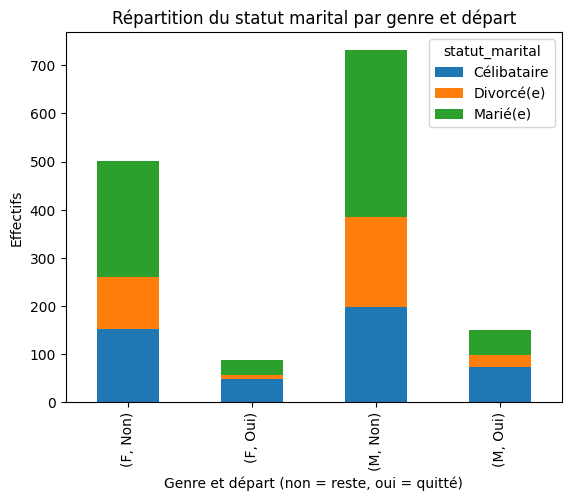

In [17]:
plt.figure(figsize=(10, 6))
table = pd.crosstab(
    [merged["genre"], merged["a_quitte_l_entreprise"]],
    merged["statut_marital"]
)

table.plot(kind="bar", stacked=True)
plt.title("Répartition du statut marital par genre et départ")
plt.xlabel("Genre et départ (non = reste, oui = quitté)")
plt.ylabel("Effectifs")
plt.show()


Ce graphique compare les niveaux de satisfaction de l’environnement de travail entre les employés ayant quitté l’entreprise et ceux restés. Les distributions sont très similaires entre les deux groupes, avec une majorité d’employés concentrée sur les niveaux de satisfaction moyens à élevés. L’absence de différence marquée suggère que cette variable est peu discriminante et qu’elle contribuera faiblement à la performance du modèle prédictif.

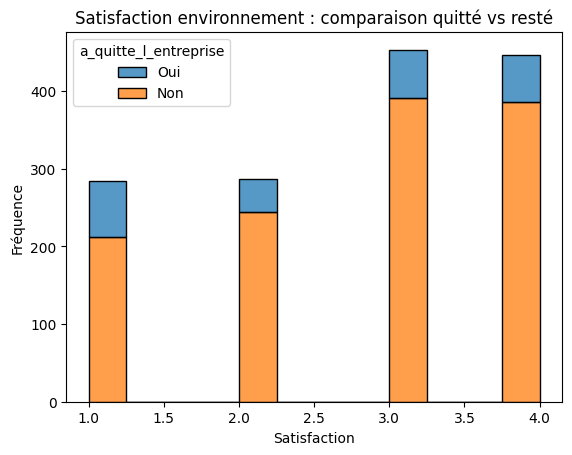

In [18]:

sns.histplot(
    merged,
    x="satisfaction_employee_environnement",
    hue="a_quitte_l_entreprise",
    multiple="stack"
)
plt.title("Satisfaction environnement : comparaison quitté vs resté")
plt.xlabel("Satisfaction")
plt.ylabel("Fréquence")
plt.show()


Cette heatmap représente les corrélations entre les variables numériques du jeu de données. On observe de fortes corrélations positives entre les variables liées à l’expérience, au poste et au revenu (par exemple entre revenu_mensuel, niveau_hierarchique_poste, annees_dans_l_entreprise et annees_dans_le_poste_actuel), indiquant une possible redondance d’information. À l’inverse, la majorité des variables de satisfaction présentent des corrélations faibles avec les autres variables, suggérant une contribution limitée et une faible multicolinéarité globale en dehors des variables liées à l’ancienneté et au niveau hiérarchique.

/var/folders/l1/4brp3mtd4h127g321s8nbxhw0000gn/T/ipykernel_45456/3004646672.py:30: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/valerianbarreau/Documents/Op_Ai_engineer/barreau_valerian_Classifiez_automatiquement_des_informations_11_2025/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


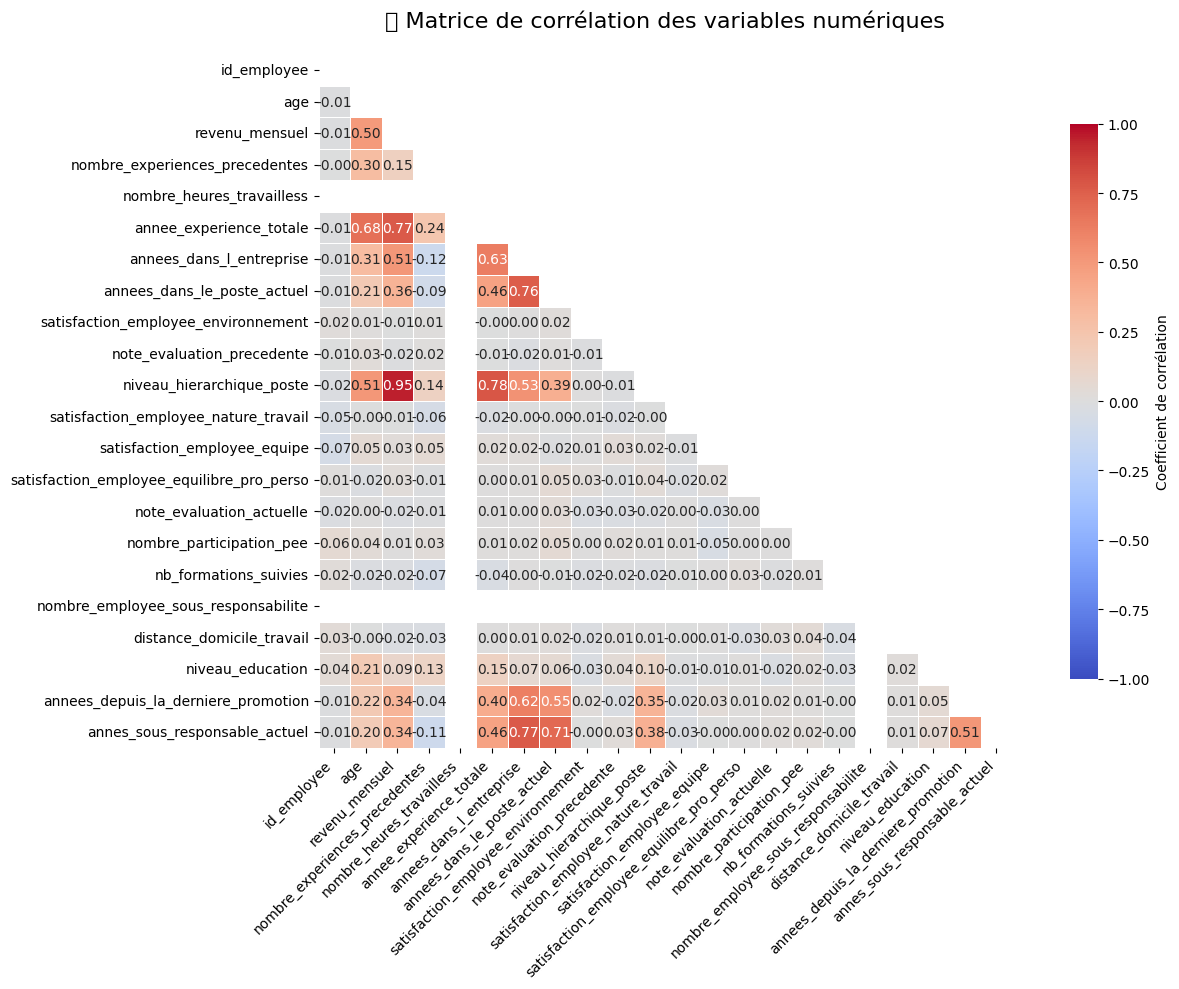

In [19]:
# 1️⃣ Sélection des colonnes numériques
num_cols = merged.select_dtypes(include=[np.number])

# 2️⃣ Calcul de la matrice de corrélation
corr = num_cols.corr()

# 3️⃣ Création d’un masque pour n’afficher que la moitié inférieure du triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4️⃣ Configuration de la figure
plt.figure(figsize=(14, 10))

# 5️⃣ Création du heatmap
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",       # Palette de couleurs centrée autour de 0
    annot=True,            # Affiche les coefficients
    fmt=".2f",             # Format des nombres (2 décimales)
    linewidths=0.5,        # Lignes de séparation
    vmin=-1, vmax=1,       # Échelle fixe de -1 à 1
    square=True,           # Cases carrées
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"}
)

# 6️⃣ Titre et mise en page
plt.title("🔢 Matrice de corrélation des variables numériques", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# 7️⃣ Affichage
plt.show()

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


REGRESSION_TARGET = "a_quitte_l_entreprise"
colonnes = [
'id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'distance_domicile_travail', 'niveau_education', 'domaine_etude',
       'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'
]

# Sélection du sous-ensemble de colonnes
merged_exercice = merged_filtered[colonnes].dropna(subset=[REGRESSION_TARGET])

# Séparation X / y
X = merged_exercice.drop(columns=REGRESSION_TARGET)
y = merged_exercice[REGRESSION_TARGET]

#  Nettoyage de la colonne avec %
if "augementation_salaire_precedente" in X.columns:
    X["augementation_salaire_precedente"] = (
        X["augementation_salaire_precedente"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("Non", "0")
        .astype(float)
    )

#  Transformation de la cible Oui/Non en 1/0
y = y.replace({"Oui": 1, "Non": 0}).astype(int)

# 🪄 Encodage des variables catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

# 🧹 Nettoyage : conversion en numérique et suppression des lignes invalides
X_encoded = X_encoded.apply(pd.to_numeric, errors="coerce")
mask = (
    X_encoded.notna().all(axis=1)
    & np.isfinite(X_encoded).all(axis=1)
    & y.notna()
    & np.isfinite(y)
)
X_clean = X_encoded.loc[mask]
y_clean = y.loc[mask]

# Utiliser X_encoded et y_clean préparés dans le notebook
X = X_encoded.copy().astype(float)
y = y_clean.astype(int).values.ravel()

# split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

strategies = ["most_frequent", "stratified", "uniform"]
for strat in strategies:
    clf = DummyClassifier(strategy=strat, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"=== Strategy: {strat} ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

    # ROC AUC si disponible
    if hasattr(clf, "predict_proba"):
        try:
            y_proba = clf.predict_proba(X_test)[:, 1]
            print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 3))
        except Exception:
            print("ROC AUC: not available for this strategy")
    print()


=== Strategy: most_frequent ===
Accuracy: 0.84
Confusion matrix:
 [[247   0]
 [ 47   0]]
Classification report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91       247
           1       0.00      0.00      0.00        47

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.71      0.84      0.77       294

ROC AUC: 0.5

=== Strategy: stratified ===
Accuracy: 0.714
Confusion matrix:
 [[204  43]
 [ 41   6]]
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       247
           1       0.12      0.13      0.12        47

    accuracy                           0.71       294
   macro avg       0.48      0.48      0.48       294
weighted avg       0.72      0.71      0.72       294

ROC AUC: 0.477

=== Strategy: uniform ===
Accuracy: 0.483
Confusion matrix:
 [[122 125]
 [ 27  20]]
Classifi

/var/folders/l1/4brp3mtd4h127g321s8nbxhw0000gn/T/ipykernel_45456/311142725.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"Oui": 1, "Non": 0}).astype(int)


In [21]:

import statsmodels.api as sm

In [22]:
REGRESSION_TARGET = "a_quitte_l_entreprise"

# 1) Sélection des colonnes
merged_exercice = merged_filtered[colonnes].dropna(subset=[REGRESSION_TARGET])

# 2) X / y
X = merged_exercice.drop(columns=REGRESSION_TARGET)
y = merged_exercice[REGRESSION_TARGET]

# 3) Nettoyage %
if "augementation_salaire_precedente" in X.columns:
    X["augementation_salaire_precedente"] = (
        X["augementation_salaire_precedente"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("Non", "0")
        .astype(float)
    )

# 4) Conversion cible Oui/Non
y = y.replace({"Oui": 1, "Non": 0}).astype(int)

# 🚨 Retirer colonnes inutiles
X = X.drop(columns=["id_employee"], errors="ignore")

# 5) Encodage
X_encoded = pd.get_dummies(X, drop_first=True)

# 6) Nettoyage final
X_encoded = X_encoded.apply(pd.to_numeric, errors="coerce")
mask = X_encoded.notna().all(axis=1) & y.notna()
X_clean = X_encoded.loc[mask]
y_clean = y.loc[mask]

# 7) Ajouter constante
X_const = sm.add_constant(X_clean).astype(float)
y_clean = y_clean.astype(float)

# 8) Modèle statsmodels
logit_model = sm.Logit(endog=y_clean, exog=X_const).fit()
print(logit_model.summary())


         Current function value: 0.292806
         Iterations: 35
                             Logit Regression Results                            
Dep. Variable:     a_quitte_l_entreprise   No. Observations:                 1470
Model:                             Logit   Df Residuals:                     1428
Method:                              MLE   Df Model:                           41
Date:                   Mon, 16 Feb 2026   Pseudo R-squ.:                  0.3371
Time:                           14:10:06   Log-Likelihood:                -430.42
converged:                         False   LL-Null:                       -649.29
Covariance Type:               nonrobust   LLR p-value:                 7.729e-68
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
age                                          -0.0313      

/var/folders/l1/4brp3mtd4h127g321s8nbxhw0000gn/T/ipykernel_45456/2411489346.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"Oui": 1, "Non": 0}).astype(int)
/Users/valerianbarreau/Documents/Op_Ai_engineer/barreau_valerian_Classifiez_automatiquement_des_informations_11_2025/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
from sklearn.linear_model import LogisticRegression

# Utiliser X_encoded (déjà encodé en dummies) et y_clean pour réentraîner la régression logistique
X = X_encoded.copy()

# convertir tous les types numériques/booleens en float
X = X.astype(float)

# ajouter constante pour statsmodels
X_const = sm.add_constant(X, has_constant='add').astype(float)

# y_clean est déjà disponible (float)
try:
    # fitting avec statsmodels
    model_dummy = sm.Logit(y_clean, X_const).fit(disp=True)
    print(model_dummy.summary())

    # prédictions et métriques
    y_prob = model_dummy.predict(X_const)
    y_pred = (y_prob >= 0.5).astype(int)

    print("\nAccuracy:", round(accuracy_score(y_clean, y_pred), 3))
    print("Confusion matrix:\n", confusion_matrix(y_clean, y_pred))
    print("\nClassification report:\n", classification_report(y_clean, y_pred))
    

except Exception as e:
    # fallback : sklearn LogisticRegression si statsmodels échoue (ex: séparation parfaite / singularité)
    print("Statsmodels Logit a échoué :", e)

    clf = LogisticRegression(max_iter=2000, solver="liblinear")
    clf.fit(X, y_clean)

    y_prob = clf.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    print("\nFallback sklearn LogisticRegression")
    print("Accuracy:", round(accuracy_score(y_clean, y_pred), 3))
    print("Confusion matrix:\n", confusion_matrix(y_clean, y_pred))
    print("\nClassification report:\n", classification_report(y_clean, y_pred))


         Current function value: 0.292806
         Iterations: 35
                             Logit Regression Results                            
Dep. Variable:     a_quitte_l_entreprise   No. Observations:                 1470
Model:                             Logit   Df Residuals:                     1427
Method:                              MLE   Df Model:                           42
Date:                   Mon, 16 Feb 2026   Pseudo R-squ.:                  0.3371
Time:                           14:10:07   Log-Likelihood:                -430.42
converged:                         False   LL-Null:                       -649.29
Covariance Type:               nonrobust   LLR p-value:                 2.547e-67
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.0005   6.2

/Users/valerianbarreau/Documents/Op_Ai_engineer/barreau_valerian_Classifiez_automatiquement_des_informations_11_2025/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.292806
         Iterations: 35


/Users/valerianbarreau/Documents/Op_Ai_engineer/barreau_valerian_Classifiez_automatiquement_des_informations_11_2025/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/l1/4brp3mtd4h127g321s8nbxhw0000gn/T/ipykernel_45456/1956935319.py:31: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_score = logit_model.predict(X_const).astype(float).ravel()


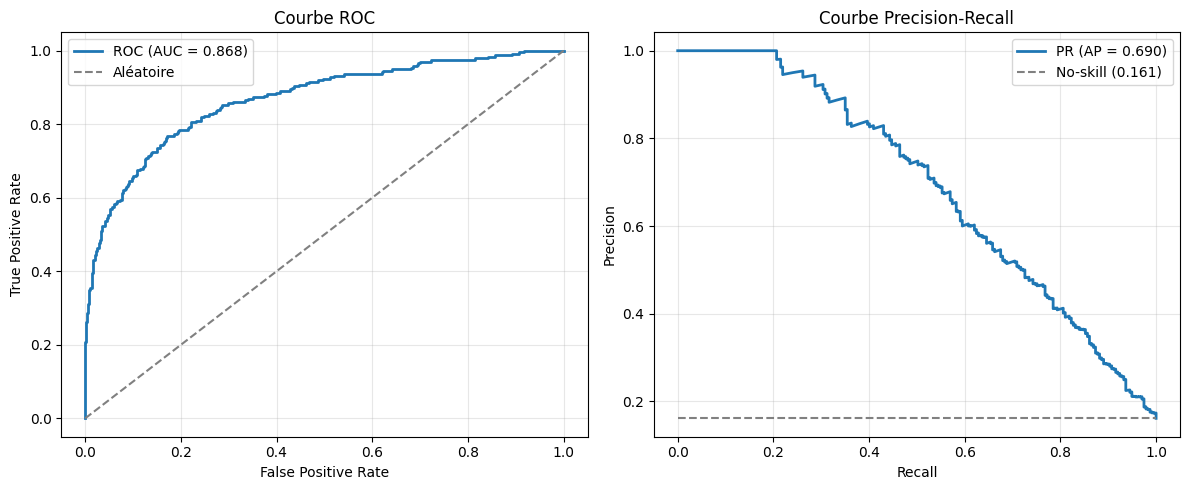

In [24]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ============================================================
# 1) Préparation des données
# ============================================================

# vos features X doivent être un DataFrame
# vos labels y_clean un vecteur


# Convertir y en float + flatten
y_true = np.asarray(y_clean, dtype=float).ravel()

# Ajouter une constante proprement (et une seule fois)
X_const = sm.add_constant(X, has_constant='add')

# ============================================================
# 2) Entraînement du modèle Logit
# ============================================================

logit_model = sm.Logit(y_true, X_const).fit()

# ============================================================
# 3) Prédictions sans erreur de dimensions
# ============================================================

# NE PAS refaire add_constant ici !!
y_score = logit_model.predict(X_const).astype(float).ravel()

# ============================================================
# 4) Calcul des métriques ROC & Precision-Recall
# ============================================================

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)

no_skill = y_true.mean()  # proportion de positifs

# ============================================================
# 5) Tracés ROC et PR
# ============================================================

plt.figure(figsize=(12,5))

# --- ROC ---
plt.subplot(1,2,1)
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Aléatoire")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.grid(alpha=0.3)

# --- PR ---
plt.subplot(1,2,2)
plt.plot(recall, precision, lw=2, label=f"PR (AP = {avg_prec:.3f})")
plt.hlines(no_skill, 0, 1, linestyle="--", color="gray", label=f"No-skill ({no_skill:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

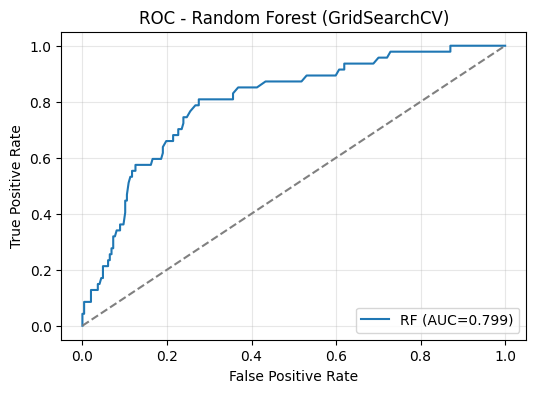

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score   
import numpy as np
from sklearn.metrics import roc_curve

    
import matplotlib.pyplot as plt

# Utiliser X_encoded et y_clean (préparés dans le notebook)
X = X_encoded.copy().astype(float)
y = y_clean.astype(int).values.ravel()

# séparation train / test stratifiée
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# grille d'hyperparamètres
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

# Lancer la recherche
gs.fit(X_train, y_train)

# Résultats
print("Best params:", gs.best_params_)
print("Best CV ROC-AUC:", gs.best_score_)

# Évaluation sur le test set
y_proba = gs.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

print("Recall:", round(recall_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("F1-Score:", round(f1_score(y_test, y_pred), 4))

# Courbe ROC simple
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"RF (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Random Forest (GridSearchCV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()